In [1]:
print("Hello AIML!")

Hello AIML!


In [1]:
import sys
print(sys.executable)

c:\Users\sasmi\OneDrive\Desktop\AIML projects\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works!")

Everything works!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(r"c:\Users\sasmi\OneDrive\Desktop\AIML projects\student-performance-predictor\data\students_performance.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\sasmi\\OneDrive\\Desktop\\AIML projects\\student-performance-predictor\\data\\students_performance.csv'

In [12]:
from pathlib import Path

data_path = Path("..") / "data" / "students_performance.csv"
print(data_path.resolve(), data_path.exists())

df = pd.read_csv(data_path)

C:\Users\sasmi\OneDrive\Desktop\AIML projects\student-performance-predictor\data\students_performance.csv False


FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\students_performance.csv'

In [13]:


df = pd.read_csv("../datas/students_performance.csv")

In [14]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86


In [15]:
df.shape

(1000, 8)

In [16]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [18]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,67.810000,70.382000,69.140000
std,15.250196,14.107413,15.025917
min,15.000000,25.000000,15.000000
25%,58.000000,61.000000,59.000000
50%,68.000000,70.500000,70.000000
75%,79.250000,80.000000,80.000000
max,100.000000,100.000000,100.000000


In [19]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [20]:
import seaborn as sns

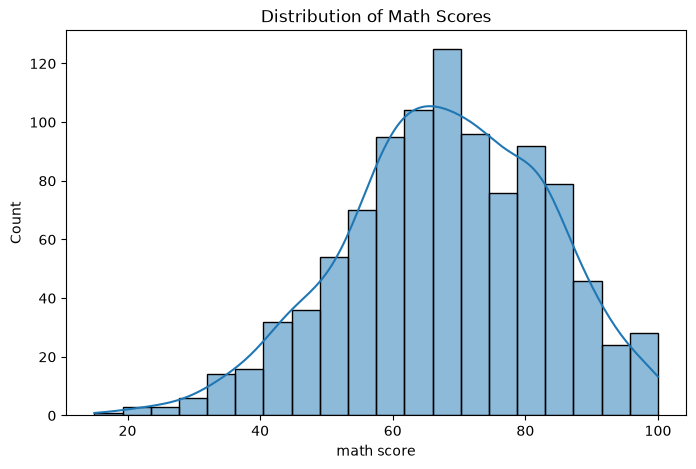

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["math score"], bins=20, kde=True)

plt.title("Distribution of Math Scores")
plt.show()

In [24]:
df[["math score", "reading score", "writing score"]].corr()

,math score,reading score,writing score
math score,1.000000,0.811767,0.790055
reading score,0.811767,1.000000,0.948909
writing score,0.790055,0.948909,1.000000


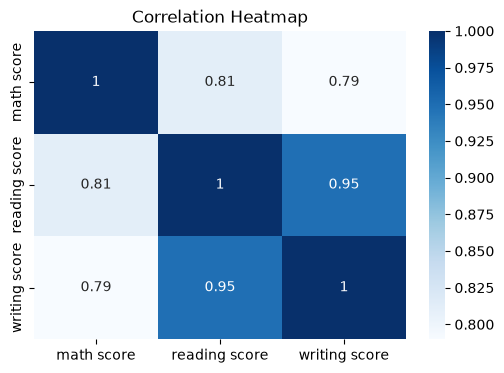

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df[["math score", "reading score", "writing score"]].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Heatmap")
plt.show()

In [25]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [26]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group D,some college,standard,completed,70,78
1,male,group D,associate's degree,standard,none,93,87
2,female,group D,some college,free/reduced,none,76,77
3,male,group B,some college,free/reduced,none,70,63
4,female,group D,associate's degree,standard,none,85,86


In [27]:
y.head()

0    59
1    96
2    57
3    70
4    83
Name: math score, dtype: int64

In [28]:
X.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
reading score                  int64
writing score                  int64
dtype: object

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [30]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numerical_cols = X.select_dtypes(include=["number"]).columns

print(categorical_cols)
print(numerical_cols)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='str')
Index(['reading score', 'writing score'], dtype='str')


In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 7)
(200, 7)
(800,)
(200,)
